# ANALYSIS 3. Solar-to-Detector Pipeline Comparison
---

This notebook compares three saved simulations generated by `notebooks/runs/solar/solar1_solar_to_detector.py`: 
1. Fully coherent amplitude pipeline,
2. Torch incoherent pipeline
3. Original Peanuts Legacy pipeline.

The comparison follows the same physical stages used in the saved files.


## 1. Libraries

We import plotting tools, Torch, the pipeline-specific loaders, and the profile loaders used to visualize the solar and Earth inputs.


In [1]:
from pathlib import Path
import os
import matplotlib.pyplot as plt
import numpy as np
import torch


from tpeanuts.flux_propagation import (
    detector_conversion_spectra_from_coherent_result,
    load_coherent_solar_detector_result,
    load_incoherent_solar_detector_result,
    load_legacypeanuts_solar_detector_result,
    relative_error_summary,
)
from tpeanuts.solar.profiles import load_default_solar_profile
from tpeanuts.io.io_earth import load_earth_density_from_csv

torch.set_printoptions(precision=6, sci_mode=True)

from tpeanuts.util.notebooks import find_repo_root, save_and_show, save_figure, show_figure
HERE = Path.cwd().resolve()
PACKAGE_DIR = find_repo_root(HERE, folder="analysis")
print(f"PACKAGE_DIR = {PACKAGE_DIR}")

plt.rcParams.update({"figure.figsize": (8, 4.8), "axes.grid": True})


PACKAGE_DIR = G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts


## 2. Simulation and System Parameters

Set the three result files below. The notebook assumes each file was created by its corresponding pipeline save routine, so loading is delegated to the matching pipeline module.


### 2.1. Paths

All notebook outputs are rooted at `DEFAULT_OUTPUT_ROOT` unless `TPEANUTS_OUTPUT_ROOT` is defined in the environment. Figures are saved under the notebook-specific `OUTPUT_DIR`; display behavior is controlled in Section 2.2.


In [2]:
DEFAULT_OUTPUT_ROOT = Path(r"V:\output")
OUTPUT_ROOT = Path(os.environ.get("TPEANUTS_OUTPUT_ROOT", DEFAULT_OUTPUT_ROOT))

OUTPUT_DATA_ROOT = Path(OUTPUT_ROOT / "data")
OUTPUT_ANALYSIS_ROOT = Path(OUTPUT_ROOT / "analysis")
OUTPUT_BENCHMARK_ROOT = Path(OUTPUT_ROOT / "benchmark")
OUTPUT_TEST_ROOT = Path(OUTPUT_ROOT / "test")

OUTPUT_DATA_ATMOSPHERE = Path(OUTPUT_DATA_ROOT / "atmosphere")
OUTPUT_DATA_SOLAR = Path(OUTPUT_DATA_ROOT / "solar")
OUTPUT_DATA_EXTERNAL = Path(OUTPUT_DATA_ROOT / "external")

OUTPUT_ANALYSIS_ATMOSPHERE = Path(OUTPUT_ANALYSIS_ROOT / "atmosphere")
OUTPUT_ANALYSIS_SOLAR = Path(OUTPUT_ANALYSIS_ROOT / "solar")
OUTPUT_ANALYSIS_EXTERNAL = Path(OUTPUT_ANALYSIS_ROOT / "external")

OUTPUT_DATA_MCEQ = Path(OUTPUT_DATA_ROOT / "mceq")
OUTPUT_DATA_HONDA = Path(OUTPUT_DATA_ROOT / "honda")

OUTPUT_DIR = OUTPUT_ANALYSIS_SOLAR / "analysis_solar3_comparison"

OUTPUT_SOLARDETECTOR_ROOT = OUTPUT_DATA_SOLAR / "detector"
COHERENT_FILE = OUTPUT_SOLARDETECTOR_ROOT / "coherent" / "solardetector_coherent.pt"
INCOHERENT_FILE = OUTPUT_SOLARDETECTOR_ROOT / "incoherent" / "solardetector_incoherent.pt"
LEGACY_FILE = OUTPUT_SOLARDETECTOR_ROOT / "legacy" / "solardetector_legacy.pt"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


print("Output root     :", OUTPUT_ROOT)
print("Output directory:", OUTPUT_DIR)


Output root     : V:\output
Output directory: V:\output\analysis\solar\analysis_solar3_comparison


### 2.2. Configuration Parameters

These parameters select the saved solar-to-detector results, numerical precision, oscillation constants, display labels, and the conversion-probability diagnostic settings. The result files are loaded here so all later sections use the same configured inputs.


In [3]:
DEVICE = "cpu"
DTYPE = torch.float64

SHOW_PLOTS = True

EARTH_DENSITY_FILE = PACKAGE_DIR / "data" / "density" / "earth_density.csv"

DM21_EV2 = 7.42e-5
DM3L_EV2 = 2.517e-3
THETA12 = 0.59
THETA13 = 0.15
THETA23 = 0.78
DELTA_CP = 1.20

CONVERSION_PRODUCTION_MODE = "incoherent"
CONVERSION_RHO_CHUNK_SIZE = 32

coherent = load_coherent_solar_detector_result(str(COHERENT_FILE), map_location=DEVICE, dtype=DTYPE)
incoherent = load_incoherent_solar_detector_result(str(INCOHERENT_FILE), map_location=DEVICE, dtype=DTYPE)
legacy = load_legacypeanuts_solar_detector_result(str(LEGACY_FILE), map_location=DEVICE, dtype=DTYPE)

DISPLAY_LABELS = {
    "coherent": "coherent",
    "incoherent": "incoherent",
    "legacy": "Peanuts Legacy",
}

results = {
    DISPLAY_LABELS["coherent"]: coherent,
    DISPLAY_LABELS["incoherent"]: incoherent,
    DISPLAY_LABELS["legacy"]: legacy,
}

SOURCE = incoherent.get("source", legacy.get("source", "8B"))
FLAVOURS = coherent.get("flavour_order", ["nue", "numu", "nutau"])
E_MEV = coherent["E_MeV"].detach().cpu().numpy()

print("Device:", DEVICE)
print("Dtype :", DTYPE)
print("Source:", SOURCE)
print("Flavour order:", FLAVOURS)
for name, data in results.items():
    print(name, "E shape", tuple(data["E_MeV"].shape), "detector integrated", tuple(data["detector_probabilities_integrated"].shape))


Device: cpu
Dtype : torch.float64
Source: 8B
Flavour order: ['nue', 'numu', 'nutau']
coherent E shape (21,) detector integrated (21, 3)
incoherent E shape (21,) detector integrated (21, 3)
Peanuts Legacy E shape (21,) detector integrated (21, 3)


## 3. Solar and Earth Profiles

The solar density $n_e(r)$ and the production profile $f_s(r)$ define where the solar state or mass mixture is created. The Earth density profile controls the matter operator $U_\oplus(E,\eta)$ used in the detector stage.


Saved figure: V:\output\analysis\solar\analysis_solar3_comparison\figure_001.png


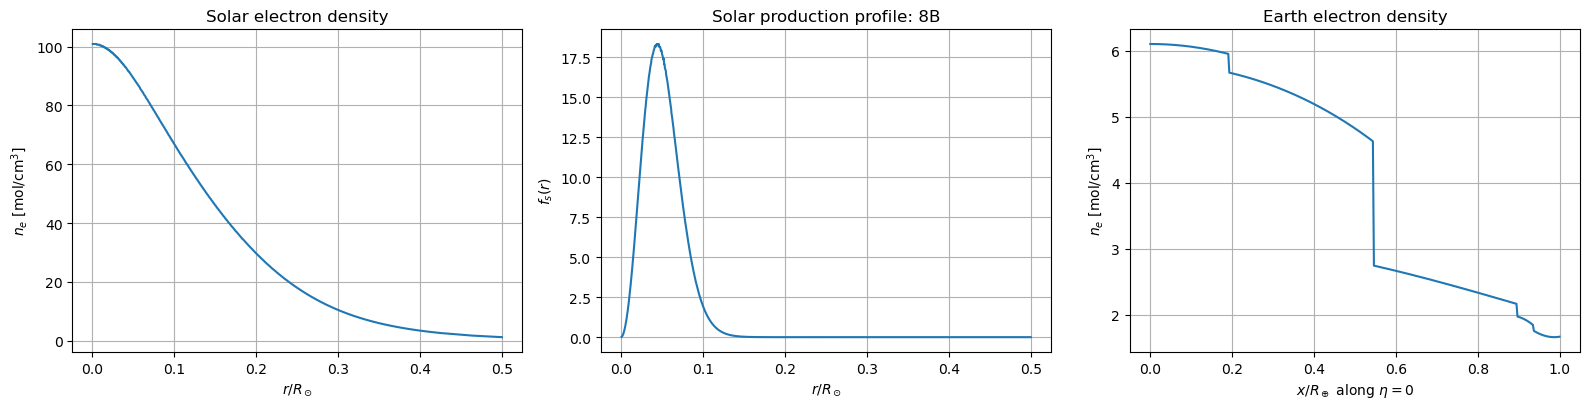

WindowsPath('V:/output/analysis/solar/analysis_solar3_comparison/figure_001.png')

In [4]:
solar_profile = load_default_solar_profile(device=DEVICE, dtype=DTYPE)
earth_density = load_earth_density_from_csv(str(EARTH_DENSITY_FILE), device=DEVICE, dtype=DTYPE)

rho = solar_profile.radius.detach().cpu().numpy()
solar_ne = solar_profile.density.detach().cpu().numpy()
production = solar_profile.normalized_fraction(SOURCE).detach().cpu().numpy()

earth_x = torch.linspace(0.0, 1.0, 400, device=DEVICE, dtype=DTYPE)
earth_eta = torch.zeros_like(earth_x)
earth_ne = earth_density.call(earth_x, earth_eta).detach().cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
axes[0].plot(rho, solar_ne)
axes[0].set_xlabel(r"$r/R_\odot$")
axes[0].set_ylabel(r"$n_e$ [mol/cm$^3$]")
axes[0].set_title("Solar electron density")

axes[1].plot(rho, production)
axes[1].set_xlabel(r"$r/R_\odot$")
axes[1].set_ylabel(r"$f_s(r)$")
axes[1].set_title(f"Solar production profile: {SOURCE}")

axes[2].plot(earth_x.detach().cpu().numpy(), earth_ne)
axes[2].set_xlabel(r"$x/R_\oplus$ along $\eta=0$")
axes[2].set_ylabel(r"$n_e$ [mol/cm$^3$]")
axes[2].set_title("Earth electron density")

fig.tight_layout()
save_and_show(output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)


## 4. Probabilities at the Solar Surface

In the coherent simulation, the solar state is propagated as an amplitude, $|\psi_\odot\rangle = U_\odot(E,\rho_0)|\psi_0\rangle$, and the plotted values are $P^\odot_\alpha = |\langle\nu_\alpha|\psi_\odot\rangle|^2$.

In the incoherent and Peanuts Legacy simulations, the solar block first builds mass weights $w_i^\odot = \int d\rho\, f_s(\rho)|U^M_{ei}(\rho,E)|^2$. Solar flavour probabilities are then $P^\odot_\alpha = \sum_i |U_{\alpha i}|^2 w_i^\odot$.


**Function flow to this point**

- Coherent: `solar_surface_state(...)` -> `surface_probabilities = abs(surface_states)**2`.
- Incoherent Torch: `solar_flux_mass(...)` -> `psolar(...)` -> `solar_probabilities`.
- Legacy PEANUTS: `peanuts.solar.solar_flux_mass(...)` -> `peanuts.solar.Psolar(...)`.


Solar-surface probability normalization:
coherent   0.9999999757856131 1.0000000409781933
incoherent 0.9999999701976776 1.0000000298023224
Peanuts Legacy 0.9999999701976776 1.0000000298023224

Max absolute differences at solar surface:
coherent - incoherent: 0.34265217185020447
incoherent - Peanuts Legacy: 0.0

Relative errors at solar surface:
coherent vs incoherent
  nue  : 1.037225e-01
  numu : 1.066562e+00
  nutau: 9.122159e-01
  total: 5.972288e-01
coherent vs Peanuts Legacy
  nue  : 1.037225e-01
  numu : 1.066562e+00
  nutau: 9.122159e-01
  total: 5.972288e-01
Saved figure: V:\output\analysis\solar\analysis_solar3_comparison\figure_002.png


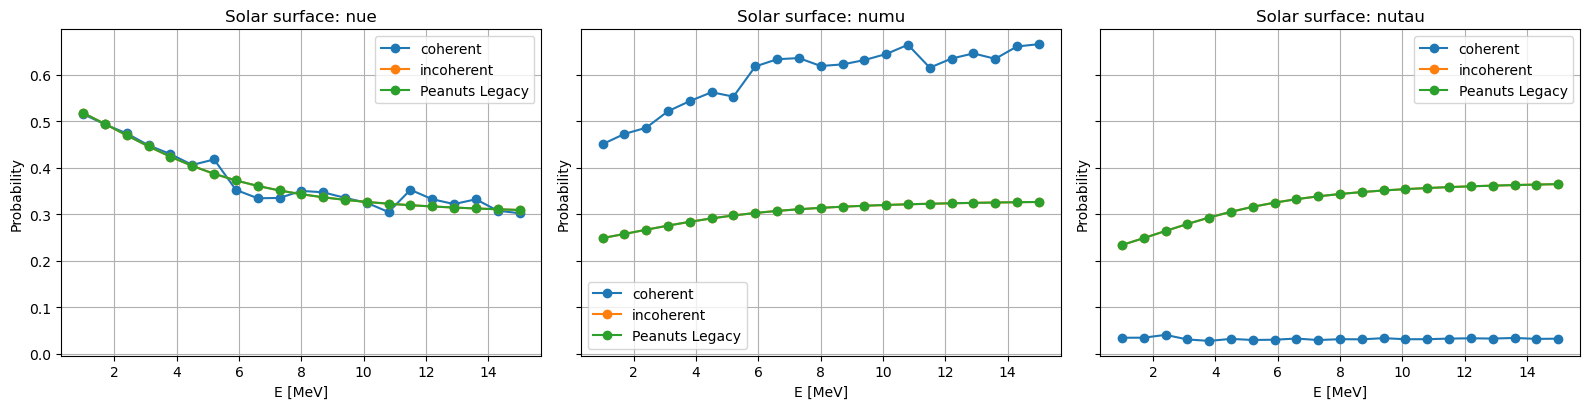

WindowsPath('V:/output/analysis/solar/analysis_solar3_comparison/figure_002.png')

In [5]:
solar_stage = {
    DISPLAY_LABELS["coherent"]: coherent["surface_probabilities"].detach().cpu().numpy(),
    DISPLAY_LABELS["incoherent"]: incoherent["solar_probabilities"].detach().cpu().numpy(),
    DISPLAY_LABELS["legacy"]: legacy["solar_probabilities"].detach().cpu().numpy(),
}

print("Solar-surface probability normalization:")
for name, values in solar_stage.items():
    print(f"{name:10s}", values.sum(axis=-1).min(), values.sum(axis=-1).max())

print("\nMax absolute differences at solar surface:")
print("coherent - incoherent:", np.max(np.abs(solar_stage[DISPLAY_LABELS["coherent"]] - solar_stage[DISPLAY_LABELS["incoherent"]])))
print("incoherent - Peanuts Legacy:", np.max(np.abs(solar_stage[DISPLAY_LABELS["incoherent"]] - solar_stage[DISPLAY_LABELS["legacy"]])))

print("\nRelative errors at solar surface:")
solar_rel = {
    "coherent vs incoherent": relative_error_summary(solar_stage[DISPLAY_LABELS["coherent"]], solar_stage[DISPLAY_LABELS["incoherent"]], flavour_order=FLAVOURS),
    "coherent vs Peanuts Legacy": relative_error_summary(solar_stage[DISPLAY_LABELS["coherent"]], solar_stage[DISPLAY_LABELS["legacy"]], flavour_order=FLAVOURS),
}
for label, summary in solar_rel.items():
    print(label)
    for flavour in FLAVOURS:
        print(f"  {flavour:5s}: {summary['by_flavour'][flavour]:.6e}")
    print(f"  total: {summary['total']:.6e}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2), sharex=True, sharey=True)
for i, flavour in enumerate(FLAVOURS):
    for name, values in solar_stage.items():
        axes[i].plot(E_MEV, values[:, i], marker="o", label=name)
    axes[i].set_title(f"Solar surface: {flavour}")
    axes[i].set_xlabel("E [MeV]")
    axes[i].set_ylabel("Probability")
    axes[i].legend()
fig.tight_layout()
save_and_show(output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)


## 5. Probabilities at Earth Arrival

For the coherent simulation, vacuum propagation from the solar surface to Earth applies $|\psi_\oplus\rangle = U_{\rm vac}(E,L)|\psi_\odot\rangle$, followed by $P^\oplus_\alpha = |\langle\nu_\alpha|\psi_\oplus\rangle|^2$.

For the incoherent and Peanuts Legacy simulations, the solar output is already a mass mixture $w_i^\odot$. Vacuum phases are not tracked, so the mass weights are unchanged and the displayed Earth-arrival flavour probabilities are the same incoherent flavour mixture derived from those weights.


**Function flow to this point**

- Coherent: `solar_to_earth_state(...)` -> `earth_probabilities = abs(earth_arrival_states)**2`.
- Incoherent Torch: `solar_flux_mass(...)` -> mass weights unchanged in vacuum -> `earth_arrival_probabilities`.
- Legacy PEANUTS: `peanuts.solar.solar_flux_mass(...)` -> mass weights unchanged in vacuum -> `earth_arrival_probabilities` saved by the wrapper.


Earth-arrival probability normalization:
coherent   0.9999999701976776 1.0000000298023224
incoherent 0.9999999701976776 1.0000000298023224
Peanuts Legacy 0.9999999701976776 1.0000000298023224

Max absolute differences at Earth arrival:
coherent - incoherent: 0.3507038652896881
incoherent - Peanuts Legacy: 0.0

Relative errors at Earth arrival:
coherent vs incoherent
  nue  : 5.932816e-01
  numu : 1.044080e+00
  nutau: 9.672312e-01
  total: 4.106728e-01
coherent vs Peanuts Legacy
  nue  : 5.932816e-01
  numu : 1.044080e+00
  nutau: 9.672312e-01
  total: 4.106728e-01
Saved figure: V:\output\analysis\solar\analysis_solar3_comparison\figure_003.png


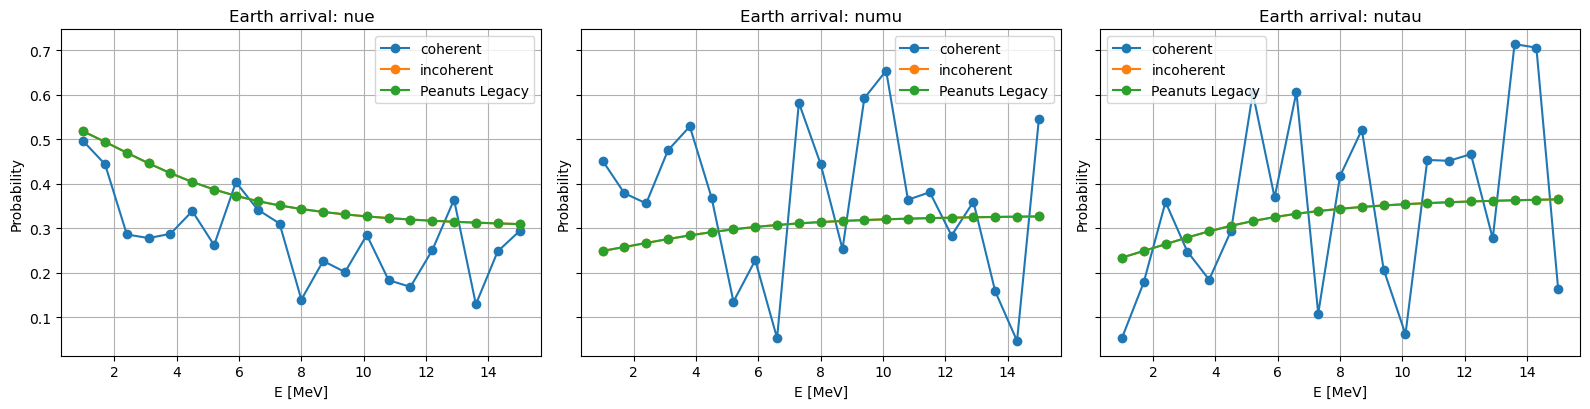

WindowsPath('V:/output/analysis/solar/analysis_solar3_comparison/figure_003.png')

In [6]:
earth_stage = {
    DISPLAY_LABELS["coherent"]: coherent["earth_probabilities"].detach().cpu().numpy(),
    DISPLAY_LABELS["incoherent"]: incoherent["earth_arrival_probabilities"].detach().cpu().numpy(),
    DISPLAY_LABELS["legacy"]: legacy["earth_arrival_probabilities"].detach().cpu().numpy(),
}

print("Earth-arrival probability normalization:")
for name, values in earth_stage.items():
    print(f"{name:10s}", values.sum(axis=-1).min(), values.sum(axis=-1).max())

print("\nMax absolute differences at Earth arrival:")
print("coherent - incoherent:", np.max(np.abs(earth_stage[DISPLAY_LABELS["coherent"]] - earth_stage[DISPLAY_LABELS["incoherent"]])))
print("incoherent - Peanuts Legacy:", np.max(np.abs(earth_stage[DISPLAY_LABELS["incoherent"]] - earth_stage[DISPLAY_LABELS["legacy"]])))

print("\nRelative errors at Earth arrival:")
earth_rel = {
    "coherent vs incoherent": relative_error_summary(earth_stage[DISPLAY_LABELS["coherent"]], earth_stage[DISPLAY_LABELS["incoherent"]], flavour_order=FLAVOURS),
    "coherent vs Peanuts Legacy": relative_error_summary(earth_stage[DISPLAY_LABELS["coherent"]], earth_stage[DISPLAY_LABELS["legacy"]], flavour_order=FLAVOURS),
}
for label, summary in earth_rel.items():
    print(label)
    for flavour in FLAVOURS:
        print(f"  {flavour:5s}: {summary['by_flavour'][flavour]:.6e}")
    print(f"  total: {summary['total']:.6e}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2), sharex=True, sharey=True)
for i, flavour in enumerate(FLAVOURS):
    for name, values in earth_stage.items():
        axes[i].plot(E_MEV, values[:, i], marker="o", label=name)
    axes[i].set_title(f"Earth arrival: {flavour}")
    axes[i].set_xlabel("E [MeV]")
    axes[i].set_ylabel("Probability")
    axes[i].legend()
fig.tight_layout()
save_and_show(output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)


## 6. Probabilities at the Detector

For the coherent simulation, Earth propagation applies $|\psi_D(E,\eta)\rangle = U_\oplus(E,\eta)|\psi_\oplus(E)\rangle$, and the nadir-dependent probabilities are $P^D_\alpha(E,\eta)=|\langle\nu_\alpha|\psi_D(E,\eta)\rangle|^2$.

For the incoherent and Peanuts Legacy simulations, Earth propagation is applied to a mass mixture: $P^D_\alpha(E,\eta)=\sum_i |(U_\oplus(E,\eta)U_{\rm PMNS})_{\alpha i}|^2 w_i^\odot(E)$.

The exposure-averaged detector probability shown below is $\bar P^D_\alpha(E)=\int d\eta\,W(\eta)P^D_\alpha(E,\eta)$.


**Function flow to this point**

- Coherent: `earth_evolutor(...)` -> `psi_detector = U_earth @ psi_earth` -> `abs(psi_detector)**2` -> exposure integral.
- Incoherent Torch: `pearth_analytical(..., massbasis=True)` -> `detector_probabilities_eta` -> exposure integral.
- Legacy PEANUTS: `peanuts.earth.Pearth(..., massbasis=True)` for each $\eta$ -> legacy exposure sum.


Detector integrated probability normalization:
coherent   1.0000000298023224 1.0000110119581223
incoherent 1.0000000596046448 1.0000155568122864
Peanuts Legacy 0.9990000426769257 0.9990140795707703

Max absolute differences at detector:
coherent - incoherent: 0.15321674942970276
incoherent - Peanuts Legacy: 0.0013474822044372559

Relative errors at detector:

 - coherent vs incoherent:     
  nue  : 3.387563e-01
  numu : 4.779796e-01
  nutau: 3.936813e-01
  total: 2.208189e-01

  - incoherent vs Peanuts Legacy: 
  nue  : 4.230036e-03
  numu : 1.041979e-03
  nutau: 1.040543e-03
  total: 1.138593e-03
Saved figure: V:\output\analysis\solar\analysis_solar3_comparison\figure_004.png


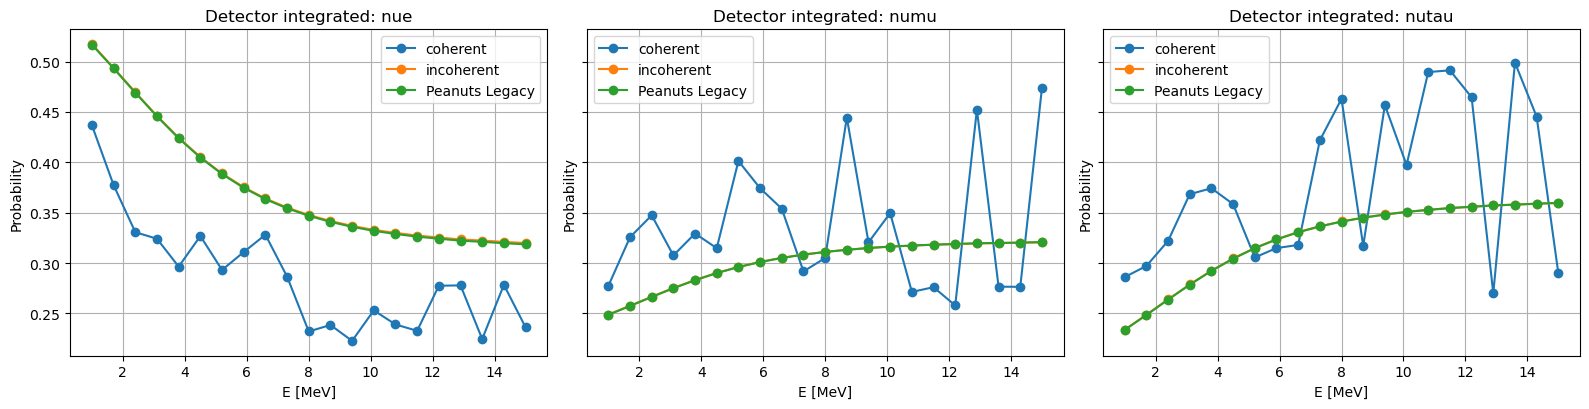

Saved figure: V:\output\analysis\solar\analysis_solar3_comparison\figure_005.png


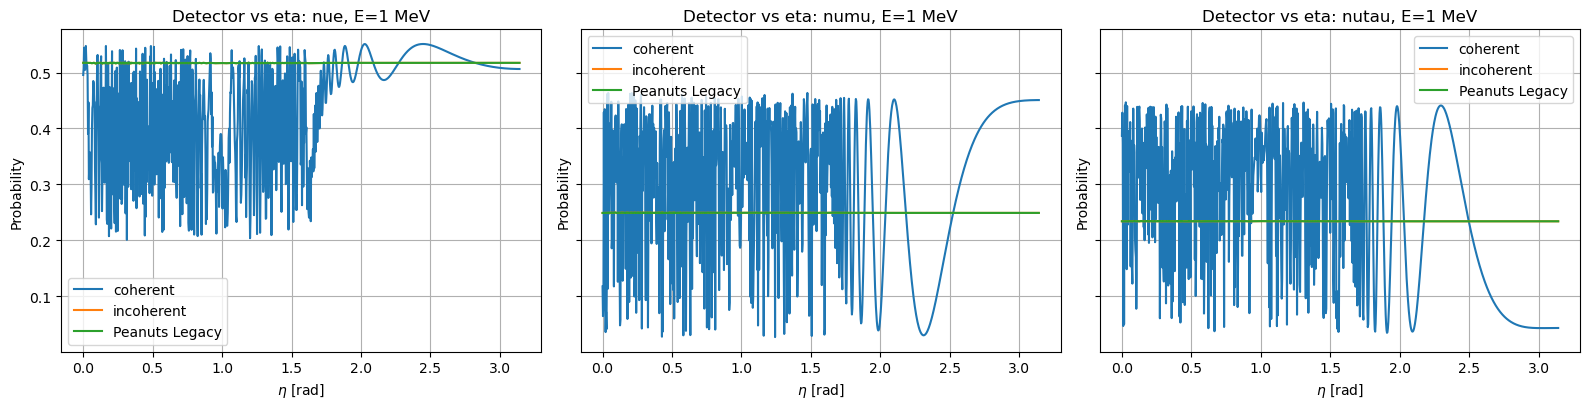

In [7]:
detector_stage = {
    DISPLAY_LABELS["coherent"]: coherent["detector_probabilities_integrated"].detach().cpu().numpy(),
    DISPLAY_LABELS["incoherent"]: incoherent["detector_probabilities_integrated"].detach().cpu().numpy(),
    DISPLAY_LABELS["legacy"]: legacy["detector_probabilities_integrated"].detach().cpu().numpy(),
}

print("Detector integrated probability normalization:")
for name, values in detector_stage.items():
    print(f"{name:10s}", values.sum(axis=-1).min(), values.sum(axis=-1).max())
    
print("\nMax absolute differences at detector:")
print("coherent - incoherent:", np.max(np.abs(detector_stage[DISPLAY_LABELS["coherent"]] - detector_stage[DISPLAY_LABELS["incoherent"]])))
print("incoherent - Peanuts Legacy:", np.max(np.abs(detector_stage[DISPLAY_LABELS["incoherent"]] - detector_stage[DISPLAY_LABELS["legacy"]])))

print("\nRelative errors at detector:")
detector_rel = {
    "- coherent vs incoherent:     ": relative_error_summary(detector_stage[DISPLAY_LABELS["coherent"]], detector_stage[DISPLAY_LABELS["incoherent"]], flavour_order=FLAVOURS),
    " - incoherent vs Peanuts Legacy: ": relative_error_summary(detector_stage[DISPLAY_LABELS["incoherent"]], detector_stage[DISPLAY_LABELS["legacy"]], flavour_order=FLAVOURS),
}


    
for label, summary in detector_rel.items():
    print('\n',label)
    for flavour in FLAVOURS:
        print(f"  {flavour:5s}: {summary['by_flavour'][flavour]:.6e}")
    print(f"  total: {summary['total']:.6e}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2), sharex=True, sharey=True)
for i, flavour in enumerate(FLAVOURS):
    
    for name, values in detector_stage.items():
        axes[i].plot(E_MEV, values[:, i], marker="o", label=name)
    axes[i].set_title(f"Detector integrated: {flavour}")
    axes[i].set_xlabel("E [MeV]")
    axes[i].set_ylabel("Probability")
    axes[i].legend()
fig.tight_layout()
save_and_show(output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

eta_values = coherent["eta"].detach().cpu().numpy()
if eta_values.size > 1:
    energy_index = 0
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.2), sharex=True, sharey=True)
    for i, flavour in enumerate(FLAVOURS):
        for name, data in results.items():
            values_eta = data["detector_probabilities_eta"].detach().cpu().numpy()
            axes[i].plot(eta_values, values_eta[energy_index, :, i], label=name)
        axes[i].set_title(f"Detector vs eta: {flavour}, E={E_MEV[energy_index]:.3g} MeV")
        axes[i].set_xlabel(r"$\eta$ [rad]")
        axes[i].set_ylabel("Probability")
        axes[i].legend()
    fig.tight_layout()
    save_and_show(output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)


## 7. Detector Conversion Spectra by Initial Flavour

This diagnostic builds the detector transition spectra $P_{\beta\to\alpha}^D(E)$ for three initial coherent flavour states. For each initial state $|\nu_\beta\rangle$, the pipeline applies the same solar, vacuum, Earth, and exposure operators used above, then plots the final probabilities into $\nu_e$, $\nu_\mu$, and $\nu_\tau$.

The plotted quantity is $\bar P_{\beta\to\alpha}^D(E)=\int d\eta\,W(\eta)P_{\beta\to\alpha}^D(E,\eta)$. The calculation uses a physical incoherent average over the solar production-radius distribution, while preserving coherent evolution along each individual path.


**Function flow to this point**

- `detector_conversion_spectra_from_coherent_result(...)` reuses the saved `E_MeV`, `rho_grid`, `rho_weights`, `eta`, `nadir_exposure`, and `earth_operators`.
- For each initial flavour: `solar_surface_state(...)` -> `vacuum_evolutor(...)` -> saved `earth_operators` -> `abs(psi_detector)**2`.
- The helper streams over `rho` chunks and returns `conversion_probabilities[initial, E, final]`.


Conversion probability normalization by initial flavour:
nue   1.000000040886686 1.0000110199228769
numu  1.00000004104705 1.0000127936255265
nutau 1.0000000287257977 1.0000081532567657
Saved figure: V:\output\analysis\solar\analysis_solar3_comparison\figure_006.png


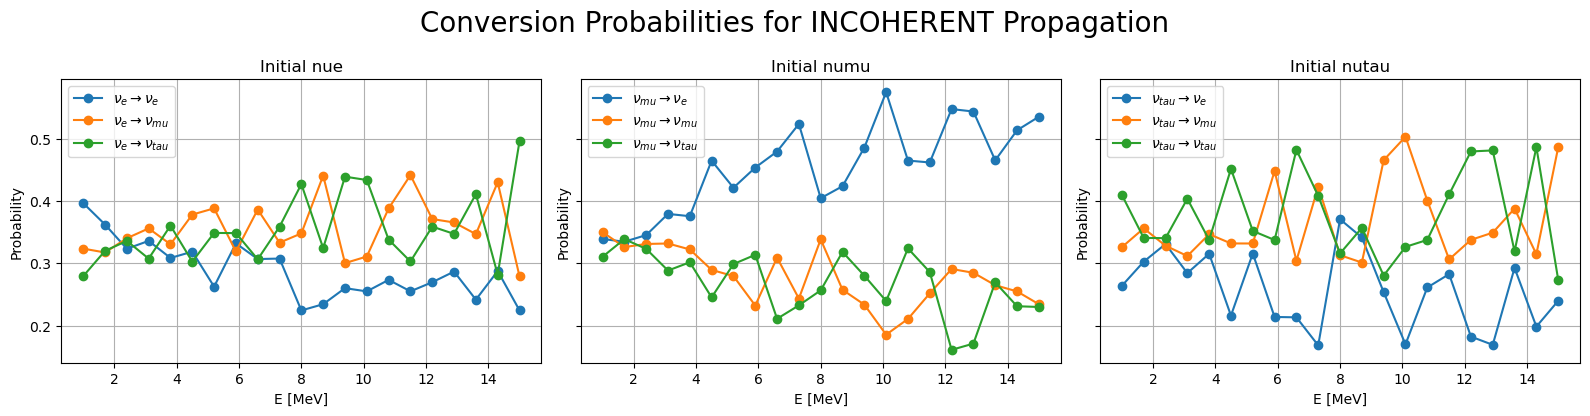

WindowsPath('V:/output/analysis/solar/analysis_solar3_comparison/figure_006.png')

In [8]:
conversion = detector_conversion_spectra_from_coherent_result(
    coherent,
    DeltamSq21=DM21_EV2,
    DeltamSq3l=DM3L_EV2,
    theta12=THETA12,
    theta13=THETA13,
    theta23=THETA23,
    delta=DELTA_CP,
    initial_flavours=tuple(FLAVOURS),
    production_mode=CONVERSION_PRODUCTION_MODE,
    solar_profile=solar_profile,
    rho_chunk_size=CONVERSION_RHO_CHUNK_SIZE,
    device=DEVICE,
    dtype=DTYPE,
)

conversion_prob = conversion["conversion_probabilities"].detach().cpu().numpy()
print("Conversion probability normalization by initial flavour:")
for i, initial in enumerate(conversion["initial_flavours"]):
    sums = conversion_prob[i].sum(axis=-1)
    print(f"{initial:5s}", sums.min(), sums.max())

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2), sharex=True, sharey=True)
for i, initial in enumerate(conversion["initial_flavours"]):
    for j, final in enumerate(conversion["final_flavours"]):
        axes[i].plot(E_MEV, conversion_prob[i, :, j], marker="o", label=rf"$\nu_{{{initial[2:]}}} \to \nu_{{{final[2:]}}}$")
    axes[i].set_title(f"Initial {initial}")
    axes[i].set_xlabel("E [MeV]")
    axes[i].set_ylabel("Probability")
    axes[i].legend()
fig.suptitle('Conversion Probabilities for INCOHERENT Propagation', fontsize=20)
fig.tight_layout()
save_and_show(output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)
